# Assignment 1
## STQD6324 Data Management
### Iris Classification using Spark MLlib

**Name:** Yang Huan  
**Matric Number:** P161796  
**Semester:** Semester 2 2025/2026

# 1.0 Introduction

Classification is one of the common tasks in machine learning. It is used to predict a category or class based on several input features. In this assignment, Spark MLlib is used to perform a classification task on the Iris dataset.

The Iris dataset is a well-known dataset that is often used in machine learning studies. It contains several measurements of iris flowers, such as sepal length, sepal width, petal length, and petal width. These features are used to predict the species of the iris flower.

In this project, three classification models will be developed using Spark MLlib. The models are Logistic Regression, Decision Tree Classifier, and Random Forest Classifier. The performance of these models will be evaluated and compared using accuracy, precision, recall, and F1-score.

Besides that, hyperparameter tuning will also be applied using grid search and cross-validation. This is done to improve the performance of the models and to select the best model for the classification task.

## 1.1 Problem Statement

The Iris dataset contains four main features, which are sepal length, sepal width, petal length, and petal width. Based on these features, the main problem is to classify each iris flower into the correct species.

This is a multi-class classification problem because the target variable contains more than two classes. In this assignment, the models need to predict whether an iris flower belongs to Iris-setosa, Iris-versicolor, or Iris-virginica.

The main challenge is to build classification models using Spark MLlib and compare their performance after model tuning. Therefore, this assignment focuses not only on building the models, but also on tuning, evaluating, and comparing them to identify the best-performing model.

## 1.2 Objectives

The objectives of this assignment are:

1. To load the Iris dataset into a Spark DataFrame.
2. To perform data preparation and preprocessing before model training.
3. To split the dataset into training and testing datasets.
4. To develop three classification models using Spark MLlib.
5. To apply grid search and cross-validation for hyperparameter tuning.
6. To evaluate the models using accuracy, precision, recall, and F1-score.
7. To generate predictions on the testing dataset.
8. To compare the performance of the three classification models.
9. To discuss the strengths and limitations of each model.
10. To justify the best-performing model based on the evaluation results.

# 2.0 Dataset Description

This section describes the dataset used in this assignment. The dataset used is the Iris dataset, which contains flower measurement data for three different iris species. Since the target variable is categorical, this dataset is suitable for a classification task.

## 2.1 Overview of the Iris Dataset

The Iris dataset is a classic dataset that is commonly used in machine learning classification problems. It contains 150 observations of iris flowers. Each observation represents one iris flower sample with several numerical measurements.

The dataset includes three species of iris flowers, which are Iris-setosa, Iris-versicolor, and Iris-virginica. Each species has 50 samples. This makes the dataset balanced and suitable for comparing the performance of different classification models.

In this assignment, the dataset is used to train and test classification models using Spark MLlib. The models will learn the relationship between the flower measurements and the iris species.

## 2.2 Features and Target Variable

The dataset contains six columns, which are Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, and Species.

The feature variables used for model training are:

1. SepalLengthCm: the length of the sepal in centimeters.
2. SepalWidthCm: the width of the sepal in centimeters.
3. PetalLengthCm: the length of the petal in centimeters.
4. PetalWidthCm: the width of the petal in centimeters.

The target variable is Species. It represents the class label that the models need to predict. The Species column contains three classes, which are Iris-setosa, Iris-versicolor, and Iris-virginica.

The Id column is only used as an identifier for each record. It does not provide useful information for classification, so it will be removed during the data preprocessing stage.

## 2.3 Source of Dataset

The Iris dataset used in this assignment was obtained from Kaggle. The dataset file used is named Iris.csv. This dataset is publicly available and is commonly used for classification practice in machine learning.

Dataset source: Kaggle - Iris Species  
Link: https://www.kaggle.com/datasets/uciml/iris

# 3.0 Data Preparation and Exploration

In this section, the Iris dataset is prepared and explored before building the classification models. The dataset is loaded into a Spark DataFrame, and some basic checking is done to understand the structure, summary statistics, and class distribution of the data.

## 3.1 Install and Import Libraries

In [ ]:
!pip install pyspark -q

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as spark_sum
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import pandas as pd

## 3.2 Create Spark Session

In [5]:
# Create Spark session
spark = SparkSession.builder \
    .appName("Iris Classification using Spark MLlib") \
    .getOrCreate()
spark

## 3.3 Upload and Load Dataset into Spark DataFrame

The Iris dataset is uploaded into Google Colab and loaded into a Spark DataFrame. The dataset is loaded with column headers, and Spark is allowed to automatically infer the data types.

In [6]:
from google.colab import files

uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [7]:
df = spark.read.csv("Iris.csv", header=True, inferSchema=True)

df.show(5)

+---+-------------+------------+-------------+------------+-----------+
| Id|SepalLengthCm|SepalWidthCm|PetalLengthCm|PetalWidthCm|    Species|
+---+-------------+------------+-------------+------------+-----------+
|  1|          5.1|         3.5|          1.4|         0.2|Iris-setosa|
|  2|          4.9|         3.0|          1.4|         0.2|Iris-setosa|
|  3|          4.7|         3.2|          1.3|         0.2|Iris-setosa|
|  4|          4.6|         3.1|          1.5|         0.2|Iris-setosa|
|  5|          5.0|         3.6|          1.4|         0.2|Iris-setosa|
+---+-------------+------------+-------------+------------+-----------+
only showing top 5 rows


## 3.4 Dataset Structure and Summary Statistics

In [8]:
df.printSchema()

root
 |-- Id: integer (nullable = true)
 |-- SepalLengthCm: double (nullable = true)
 |-- SepalWidthCm: double (nullable = true)
 |-- PetalLengthCm: double (nullable = true)
 |-- PetalWidthCm: double (nullable = true)
 |-- Species: string (nullable = true)



In [9]:
df.describe().show()

+-------+------------------+------------------+-------------------+------------------+------------------+--------------+
|summary|                Id|     SepalLengthCm|       SepalWidthCm|     PetalLengthCm|      PetalWidthCm|       Species|
+-------+------------------+------------------+-------------------+------------------+------------------+--------------+
|  count|               150|               150|                150|               150|               150|           150|
|   mean|              75.5| 5.843333333333335| 3.0540000000000007|3.7586666666666693|1.1986666666666672|          NULL|
| stddev|43.445367992456916|0.8280661279778637|0.43359431136217375| 1.764420419952262|0.7631607417008414|          NULL|
|    min|                 1|               4.3|                2.0|               1.0|               0.1|   Iris-setosa|
|    max|               150|               7.9|                4.4|               6.9|               2.5|Iris-virginica|
+-------+------------------+----

In [10]:
# Display number of rows and columns
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

Number of rows: 150
Number of columns: 6


## 3.5 Class Distribution

The distribution of the target variable is checked to see whether the three iris species have balanced samples.

In [11]:
# Count the number of samples for each iris species
df.groupBy("Species").count().show()

+---------------+-----+
|        Species|count|
+---------------+-----+
| Iris-virginica|   50|
|    Iris-setosa|   50|
|Iris-versicolor|   50|
+---------------+-----+



## 3.6 Interpretation of Data Exploration

Based on the initial exploration, the Iris dataset contains 150 records and 6 columns. The dataset includes four numerical feature columns and one target column named Species. The class distribution shows that the dataset is balanced because each iris species has the same number of samples. This is useful for classification because the models can learn from each class equally.

# 4.0 Data Preprocessing

In this section, data preprocessing is performed before model training. The preprocessing steps include checking missing values, removing unnecessary columns, converting the target variable into numerical labels, and combining the feature columns into a single feature vector.

## 4.1 Check Missing Values

Missing values are checked to ensure that the dataset is complete before training the classification models.

In [12]:
missing_values = df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

In [13]:
missing_values.show()

+---+-------------+------------+-------------+------------+-------+
| Id|SepalLengthCm|SepalWidthCm|PetalLengthCm|PetalWidthCm|Species|
+---+-------------+------------+-------------+------------+-------+
|  0|            0|           0|            0|           0|      0|
+---+-------------+------------+-------------+------------+-------+



## 4.2 Remove Unnecessary Columns
The Id column is removed because it is only an identifier and does not help the model predict the iris species.

In [14]:

df_cleaned = df.drop("Id")

df_cleaned.show(5)

+-------------+------------+-------------+------------+-----------+
|SepalLengthCm|SepalWidthCm|PetalLengthCm|PetalWidthCm|    Species|
+-------------+------------+-------------+------------+-----------+
|          5.1|         3.5|          1.4|         0.2|Iris-setosa|
|          4.9|         3.0|          1.4|         0.2|Iris-setosa|
|          4.7|         3.2|          1.3|         0.2|Iris-setosa|
|          4.6|         3.1|          1.5|         0.2|Iris-setosa|
|          5.0|         3.6|          1.4|         0.2|Iris-setosa|
+-------------+------------+-------------+------------+-----------+
only showing top 5 rows


## 4.3 Label Encoding using StringIndexer

The target variable, Species, is a categorical variable. Since Spark MLlib requires numerical labels for classification models, StringIndexer is used to convert the Species column into a numerical label column.

In [15]:
label_indexer = StringIndexer(
    inputCol="Species",
    outputCol="label"
)

df_indexed = label_indexer.fit(df_cleaned).transform(df_cleaned)

df_indexed.select("Species", "label").show(10)

+-----------+-----+
|    Species|label|
+-----------+-----+
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
|Iris-setosa|  0.0|
+-----------+-----+
only showing top 10 rows


## 4.4 Feature Vector Creation using VectorAssembler
VectorAssembler is used to combine all numerical feature columns into one features column, which is required by Spark MLlib models.

In [16]:
# Define feature columns
feature_columns = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

# Combine feature columns into a single vector column
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

final_data = assembler.transform(df_indexed)

# Display features and label columns
final_data.select("features", "label").show(5, truncate=False)

+-----------------+-----+
|features         |label|
+-----------------+-----+
|[5.1,3.5,1.4,0.2]|0.0  |
|[4.9,3.0,1.4,0.2]|0.0  |
|[4.7,3.2,1.3,0.2]|0.0  |
|[4.6,3.1,1.5,0.2]|0.0  |
|[5.0,3.6,1.4,0.2]|0.0  |
+-----------------+-----+
only showing top 5 rows


## 4.5 Final Prepared Dataset

After preprocessing, the dataset is ready for model training. The final dataset contains a features column as the input variables and a label column as the target variable.

In [17]:
model_data = final_data.select("features", "label", "Species")
model_data.show(5, truncate=False)

+-----------------+-----+-----------+
|features         |label|Species    |
+-----------------+-----+-----------+
|[5.1,3.5,1.4,0.2]|0.0  |Iris-setosa|
|[4.9,3.0,1.4,0.2]|0.0  |Iris-setosa|
|[4.7,3.2,1.3,0.2]|0.0  |Iris-setosa|
|[4.6,3.1,1.5,0.2]|0.0  |Iris-setosa|
|[5.0,3.6,1.4,0.2]|0.0  |Iris-setosa|
+-----------------+-----+-----------+
only showing top 5 rows


## 4.6 Interpretation of Data Preprocessing

The preprocessing stage prepares the Iris dataset for Spark MLlib classification models. No missing values are expected in this dataset. The Id column is removed because it is not useful for prediction. The Species column is converted into a numerical label, and the four measurement columns are combined into a single features column. After these steps, the dataset is in the correct format for model training.

# 5.0 Train-Test Split

In this section, the prepared dataset is split into training and testing datasets. The training dataset is used to train the classification models, while the testing dataset is used to evaluate how well the trained models perform on unseen data.

In this assignment, 80% of the data is used for training and 20% is used for testing. A random seed is also set to make the result reproducible.

In [18]:
train_data, test_data = model_data.randomSplit([0.8, 0.2], seed=42)

In [19]:
print("Training data count:", train_data.count())
print("Testing data count:", test_data.count())

Training data count: 126
Testing data count: 24


## 5.1 Interpretation of Train-Test Split

The dataset has been split into training and testing sets using an 80:20 ratio. The training data will be used to build the classification models, while the testing data will be used to evaluate the performance of the models. This step is important because it helps to check whether the models can make good predictions on data that they have not seen before.

# 6.0 Model Development, Tuning and Prediction

In this section, three classification models are developed using Spark MLlib. The models selected are Logistic Regression, Decision Tree Classifier, and Random Forest Classifier. These models are chosen because they are commonly used classification algorithms and they can be implemented directly using Spark MLlib.

For each model, hyperparameter tuning is performed using grid search and cross-validation. After tuning, the best model is used to generate predictions on the testing dataset.

## 6.1 Logistic Regression

### 6.1.1 Model Development

Logistic Regression is used as the first classification model. Although it is usually known for binary classification, Spark MLlib also supports Logistic Regression for multi-class classification problems.

In [20]:
# Create Logistic Regression model
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

### 6.1.2 Hyperparameter Tuning using Grid Search and Cross-Validation

Grid search is used to test different combinations of hyperparameters. Cross-validation is used to evaluate each combination and select the best Logistic Regression model.

In [21]:
# Create parameter grid for Logistic Regression
lr_param_grid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1]) \
    .addGrid(lr.maxIter, [10, 50]) \
    .build()

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

# Create CrossValidator for Logistic Regression
lr_cv = CrossValidator(
    estimator=lr,
    estimatorParamMaps=lr_param_grid,
    evaluator=accuracy_evaluator,
    numFolds=3
)

lr_cv_model = lr_cv.fit(train_data)

### 6.1.3 Prediction on Testing Dataset

After the best Logistic Regression model is selected, it is used to generate predictions on the testing dataset.

In [22]:
lr_predictions = lr_cv_model.transform(test_data)

lr_predictions.select("Species", "label", "prediction", "probability").show(10, truncate=False)

+---------------+-----+----------+---------------------------------------------------------------+
|Species        |label|prediction|probability                                                    |
+---------------+-----+----------+---------------------------------------------------------------+
|Iris-setosa    |0.0  |0.0       |[0.9736607681787879,0.02633854399256861,6.878286435337349E-7]  |
|Iris-setosa    |0.0  |0.0       |[0.9771051171708133,0.022894330723792083,5.521053946243328E-7] |
|Iris-setosa    |0.0  |0.0       |[0.9949015797628573,0.005098371573469943,4.866367273937873E-8] |
|Iris-setosa    |0.0  |0.0       |[0.9488387338563854,0.05115951042297816,1.7557206364894085E-6] |
|Iris-setosa    |0.0  |0.0       |[0.9496296617674636,0.05036932435175217,1.0138807844638025E-6] |
|Iris-versicolor|1.0  |1.0       |[0.09894969667914973,0.8860331184583286,0.0150171848625216]    |
|Iris-setosa    |0.0  |0.0       |[0.9794868672695339,0.020512664887365827,4.6784310003259807E-7]|
|Iris-seto

### 6.1.4 Model Evaluation

The Logistic Regression model will be evaluated using accuracy, precision, recall, and F1-score in the model evaluation section.

## 6.2 Decision Tree Classifier

### 6.2.1 Model Development

Decision Tree Classifier is used as the second classification model. This model works by splitting the data into different branches based on feature values. It is easy to understand and interpret compared to some other machine learning models.

In [23]:
# Create Decision Tree Classifier model
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label"
)

### 6.2.2 Hyperparameter Tuning using Grid Search and Cross-Validation

For the Decision Tree model, grid search is used to test different tree depths and impurity criteria. Cross-validation is then used to select the best parameter combination.

In [26]:
# Create parameter grid for Decision Tree
dt_param_grid = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [3, 5, 7]) \
    .addGrid(dt.impurity, ["gini", "entropy"]) \
    .build()

# Create CrossValidator for Decision Tree
dt_cv = CrossValidator(
    estimator=dt,
    estimatorParamMaps=dt_param_grid,
    evaluator=accuracy_evaluator,
    numFolds=3
)

In [27]:
dt_cv_model = dt_cv.fit(train_data)

### 6.2.3 Prediction on Testing Dataset

After tuning, the best Decision Tree model is used to predict the species of iris flowers in the testing dataset.

In [45]:
dt_predictions = dt_cv_model.transform(test_data)
dt_predictions.select("Species", "label", "prediction", "probability").show(10, truncate=False)

+---------------+-----+----------+-------------+
|Species        |label|prediction|probability  |
+---------------+-----+----------+-------------+
|Iris-setosa    |0.0  |0.0       |[1.0,0.0,0.0]|
|Iris-setosa    |0.0  |0.0       |[1.0,0.0,0.0]|
|Iris-setosa    |0.0  |0.0       |[1.0,0.0,0.0]|
|Iris-setosa    |0.0  |0.0       |[1.0,0.0,0.0]|
|Iris-setosa    |0.0  |0.0       |[1.0,0.0,0.0]|
|Iris-versicolor|1.0  |1.0       |[0.0,1.0,0.0]|
|Iris-setosa    |0.0  |0.0       |[1.0,0.0,0.0]|
|Iris-setosa    |0.0  |0.0       |[1.0,0.0,0.0]|
|Iris-setosa    |0.0  |0.0       |[1.0,0.0,0.0]|
|Iris-versicolor|1.0  |1.0       |[0.0,1.0,0.0]|
+---------------+-----+----------+-------------+
only showing top 10 rows


### 6.2.4 Model Evaluation

The tuned Decision Tree model will be evaluated later using the same evaluation metrics as the other models.

## 6.3 Random Forest Classifier

### 6.3.1 Model Development

Random Forest Classifier is used as the third classification model. It is an ensemble learning method that builds multiple decision trees and combines their results to make predictions. This can help improve prediction performance and reduce overfitting.

In [30]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42
)

### 6.3.2 Hyperparameter Tuning using Grid Search and Cross-Validation

For the Random Forest model, grid search is used to test different numbers of trees and different maximum depths. Cross-validation is applied to select the best Random Forest model.

In [31]:
# Create parameter grid for Random Forest
rf_param_grid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 20]) \
    .addGrid(rf.maxDepth, [3, 5, 7]) \
    .build()

rf_cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=rf_param_grid,
    evaluator=accuracy_evaluator,
    numFolds=3
)

rf_cv_model = rf_cv.fit(train_data)

### 6.3.3 Prediction on Testing Dataset

In [32]:
rf_predictions = rf_cv_model.transform(test_data)

rf_predictions.select("Species", "label", "prediction", "probability").show(10, truncate=False)

+---------------+-----+----------+-------------------------------------------------------------+
|Species        |label|prediction|probability                                                  |
+---------------+-----+----------+-------------------------------------------------------------+
|Iris-setosa    |0.0  |0.0       |[0.9833333333333334,0.016666666666666666,0.0]                |
|Iris-setosa    |0.0  |0.0       |[0.9833333333333334,0.016666666666666666,0.0]                |
|Iris-setosa    |0.0  |0.0       |[1.0,0.0,0.0]                                                |
|Iris-setosa    |0.0  |0.0       |[0.9833333333333334,0.016666666666666666,0.0]                |
|Iris-setosa    |0.0  |0.0       |[0.9833333333333334,0.016666666666666666,0.0]                |
|Iris-versicolor|1.0  |1.0       |[0.03333333333333333,0.9403381122459654,0.026328554420701207]|
|Iris-setosa    |0.0  |0.0       |[1.0,0.0,0.0]                                                |
|Iris-setosa    |0.0  |0.0    

### 6.3.4 Model Evaluation

The tuned Random Forest model will be evaluated using the same evaluation metrics as Logistic Regression and Decision Tree.

## 6.4 Interpretation of Model Development and Tuning

Three classification models have been developed using Spark MLlib. Grid search and cross-validation were applied to each model to find better hyperparameter settings. After tuning, each model was used to generate predictions on the testing dataset.

Using the same training and testing data for all three models makes the comparison fair. The prediction results will be evaluated in the next section using accuracy, precision, recall, and F1-score.

# 7.0 Model Evaluation Results

In this section, the performance of the three tuned classification models is evaluated. The models are evaluated using accuracy, precision, recall, and F1-score. These metrics are used because this assignment is a multi-class classification task, and they can provide a better understanding of the model performance.

## 7.1 Evaluation Metrics

The following evaluation metrics are used in this assignment:

- Accuracy measures the overall percentage of correct predictions.
- Precision measures how many predicted positive results are actually correct.
- Recall measures how many actual class samples are correctly predicted.
- F1-score combines precision and recall into one balanced metric.

These metrics are useful because they allow the performance of the three classification models to be compared more clearly.

In [33]:
# Create evaluators for different metrics
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

## 7.2 Accuracy, Precision, Recall and F1-Score Results

The evaluation scores for Logistic Regression, Decision Tree Classifier, and Random Forest Classifier are calculated and stored in a table. This makes it easier to compare the performance of the three models.

In [35]:
def evaluate_model(predictions, model_name):
    accuracy = accuracy_evaluator.evaluate(predictions)
    precision = precision_evaluator.evaluate(predictions)
    recall = recall_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

In [36]:
# Evaluate all three models
results = []
results.append(evaluate_model(lr_predictions, "Logistic Regression"))
results.append(evaluate_model(dt_predictions, "Decision Tree Classifier"))
results.append(evaluate_model(rf_predictions, "Random Forest Classifier"))


In [37]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree Classifier,1.0,1.0,1.0,1.0
2,Random Forest Classifier,1.0,1.0,1.0,1.0


In [39]:
results_df_rounded = results_df.copy()

for col_name in ["Accuracy", "Precision", "Recall", "F1-score"]:
    results_df_rounded[col_name] = results_df_rounded[col_name].round(4)

results_df_rounded

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree Classifier,1.0,1.0,1.0,1.0
2,Random Forest Classifier,1.0,1.0,1.0,1.0


## 7.3 Best Model Based on Evaluation Results

The best-performing model is selected based on the evaluation results. In this assignment, accuracy and F1-score are considered important because they show the overall prediction performance and the balance between precision and recall.
Since all three models achieved the same evaluation scores, the final model selection will also consider model simplicity, interpretability, and efficiency.

In [41]:
best_model = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]

best_model

,0
Model,Logistic Regression
Accuracy,1.0
Precision,1.0
Recall,1.0
F1-score,1.0


## 7.4 Interpretation of Model Evaluation Results

Based on the evaluation results, all three models achieved the same performance in this experiment. Logistic Regression, Decision Tree Classifier, and Random Forest Classifier all obtained an accuracy, precision, recall, and F1-score of 1.0000. This means that all three models correctly classified the testing samples.

The high performance may be because the Iris dataset is relatively small, balanced, and the three iris species can be separated well using the sepal and petal measurements. Since the dataset is balanced, accuracy is a suitable metric. However, precision, recall, and F1-score are also included to provide a more complete evaluation.

Although all three models achieved the same scores, model selection should also consider simplicity, interpretability, and computational cost. Therefore, the final selection of the best model will be discussed further in the comparative analysis section.

# 8.0 Model Comparison and Comparative Analysis

In this section, the performance of the three classification models is compared. The comparison is based on accuracy, precision, recall, and F1-score. Besides the numerical results, the strengths and limitations of each model are also discussed to better understand their performance.

## 8.1 Performance Comparison across the Three Models

In [42]:
# Display the comparison table
results_df_rounded

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree Classifier,1.0,1.0,1.0,1.0
2,Random Forest Classifier,1.0,1.0,1.0,1.0


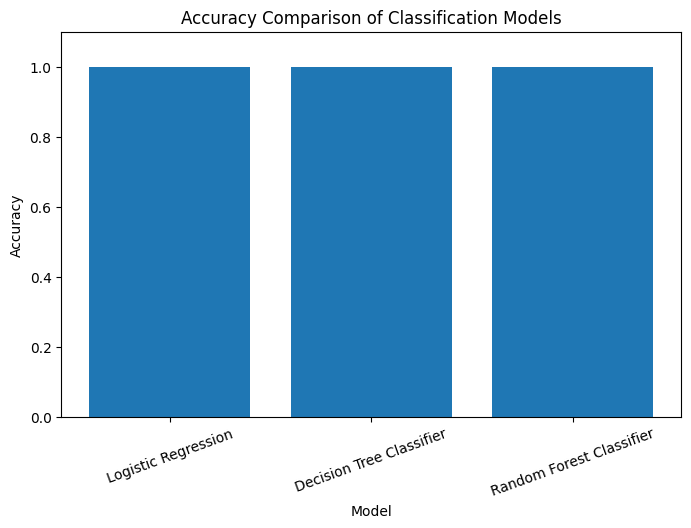

In [44]:
import matplotlib.pyplot as plt

# Plot accuracy comparison
plt.figure(figsize=(8, 5))
plt.bar(results_df_rounded["Model"], results_df_rounded["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Classification Models")
plt.xticks(rotation=20)
plt.ylim(0, 1.1)
plt.show()

Based on the results, all three models achieved the same performance on the testing dataset. Logistic Regression, Decision Tree Classifier, and Random Forest Classifier all obtained an accuracy, precision, recall, and F1-score of 1.0000.

This means that all three tuned models were able to correctly classify all samples in the testing dataset. The high performance may be due to the Iris dataset being small, balanced, and relatively easy to separate using the flower measurement features.

## 8.2 Strengths and Limitations of Logistic Regression

Logistic Regression performed very well in this experiment. One strength of Logistic Regression is that it is simple and efficient. It is also easier to interpret compared to more complex models. Since the Iris dataset has clear numerical features, Logistic Regression was able to classify the flower species accurately.

However, Logistic Regression also has some limitations. It may not perform as well when the relationship between the features and the target variable is highly non-linear. For more complex datasets, Logistic Regression may not be flexible enough compared to tree-based models.

## 8.3 Strengths and Limitations of Decision Tree

Decision Tree Classifier is easy to understand because it makes decisions by splitting the data based on feature values. This makes the model more interpretable. It can also handle non-linear relationships better than Logistic Regression.

However, one limitation of Decision Tree is that it can overfit the training data, especially when the tree is too deep. If overfitting happens, the model may perform well on training data but not as well on testing data. Therefore, tuning parameters such as maxDepth is important.

## 8.4 Strengths and Limitations of Random Forest

Random Forest Classifier is an ensemble model that combines multiple decision trees. One strength of Random Forest is that it can reduce overfitting compared to a single Decision Tree. It usually gives stable and strong prediction performance because it uses the results from many trees.

However, Random Forest is less interpretable than a single Decision Tree. It also requires more computational resources because it builds multiple trees. For a small dataset like the Iris dataset, the improvement may not always be very large compared to simpler models.

## 8.5 Justification of the Best-Performing Model

Based on the evaluation results, all three models achieved the same performance, with an accuracy, precision, recall, and F1-score of 1.0000. This shows that Logistic Regression, Decision Tree Classifier, and Random Forest Classifier were all able to correctly classify the testing samples in this experiment.

Although the three models produced the same evaluation scores, Logistic Regression is selected as the most suitable model for this classification task. This is because it achieved the same perfect performance as the other models while being simpler, faster, and easier to interpret.

Decision Tree Classifier and Random Forest Classifier also performed well. However, Decision Tree may be more likely to overfit if the tree becomes too deep, while Random Forest requires more computational resources because it builds multiple trees. Since the Iris dataset is small and the classes can be separated well using the given features, a simpler model such as Logistic Regression is sufficient for this task.

Therefore, Logistic Regression is chosen as the best model in this assignment, not because it has higher evaluation scores than the other models, but because it provides the same performance with a simpler and more efficient model structure.

# 9.0 Conclusion

In this assignment, Spark MLlib was used to perform a classification task on the Iris dataset. The dataset was first loaded into a Spark DataFrame, followed by data exploration and preprocessing. The Species column was converted into a numerical label, and the feature columns were combined into a single features vector for model training.

Three classification models were developed in this assignment, which were Logistic Regression, Decision Tree Classifier, and Random Forest Classifier. Grid search and cross-validation were applied to tune the hyperparameters of each model. After tuning, the models were used to generate predictions on the testing dataset.

The models were evaluated using accuracy, precision, recall, and F1-score. Based on the evaluation results, all three models achieved the same performance, with all metrics equal to 1.0000. This shows that the three models were able to classify the iris species correctly in this experiment.

Although all three models achieved perfect scores, Logistic Regression was selected as the most suitable model for this task. This is because it produced the same performance as Decision Tree and Random Forest, but it is simpler, faster, and easier to interpret. Since the Iris dataset is small and the classes can be separated well using the flower measurement features, Logistic Regression is sufficient for this classification problem.

Overall, this assignment shows how Spark MLlib can be used to build, tune, evaluate, and compare classification models. It also shows the importance of model evaluation and comparison before selecting the final model.